# 🌌 Hearing Two Black Holes Collide

### Reproducing a Nobel Prize–winning discovery, live, in a Jupyter notebook

<img src="images/ligo_hanford.jpg" width="720" alt="Aerial view of LIGO Hanford">

*LIGO Hanford Observatory, Washington. Each arm of the "L" is **4 km** long. (Image: LIGO Laboratory, public domain)*

---

On **14 September 2015, at 09:50:45 UTC**, two detectors 3,000 km apart, one in Washington and one in Louisiana,
each twitched for about **0.2 seconds**.

That twitch was the first gravitational wave ever detected: a ripple in space itself, made by two black holes
colliding **1.3 billion years ago**. It won the **2017 Nobel Prize in Physics**.

LIGO publishes its data openly. In the next few minutes we'll **download the real data** and turn it into a discovery,
mixing explanation, math, code, plots and sound in one document.

In [18]:
# Setup: the tools we'll use
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Audio, Markdown, display
import ipywidgets as widgets
import astropy.units as u
import astropy.constants as const

from gwpy.timeseries import TimeSeries

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({"figure.figsize": (11, 4), "font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"H1": "#ee0000", "L1": "#4ba6ff"}
NAMES = {"H1": "LIGO Hanford", "L1": "LIGO Livingston"}

## 1. What is a gravitational wave?

In 1915 Einstein showed that **gravity is the curvature of space and time**. Matter tells spacetime how to curve,
and curved spacetime tells matter how to move:

$$
\underbrace{G_{\mu\nu}}_{\text{curvature of spacetime}} \;=\; \frac{8\pi G}{c^4}\,\underbrace{T_{\mu\nu}}_{\text{matter \& energy}}
$$

When heavy objects **accelerate**, for example two black holes whirling around each other, they send out ripples in that
curvature at the speed of light. These are **gravitational waves**.

When a wave passes, it **stretches space in one direction while squeezing it in the other**. Here is a ring of
floating particles as a wave passes through the screen (the effect is exaggerated by about $10^{20}$):

In [19]:
# Animate a ring of free-floating particles as a gravitational wave passes through them
theta = np.linspace(0, 2 * np.pi, 24, endpoint=False)
x0, y0 = np.cos(theta), np.sin(theta)
h = 0.35  # wave amplitude, hugely exaggerated

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
dots = []
for ax, title in zip(axes, ["'Plus' (+) polarization", "'Cross' (×) polarization"]):
    ax.set(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), aspect="equal", xticks=[], yticks=[], title=title)
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", color="gray", alpha=0.5))
    dots.append(ax.scatter(x0, y0, s=60, c=theta, cmap="twilight"))

def frame(i):
    s = h * np.sin(2 * np.pi * i / 40)
    dots[0].set_offsets(np.c_[x0 * (1 + s / 2), y0 * (1 - s / 2)])
    dots[1].set_offsets(np.c_[x0 + s / 2 * y0, y0 + s / 2 * x0])
    return dots

anim = animation.FuncAnimation(fig, frame, frames=40, interval=50)
plt.close(fig)
HTML(anim.to_jshtml())

How big is the real effect? Physicists describe it with the **strain** $h$, the fractional change in length:

$$
h = \frac{\Delta L}{L} \approx 10^{-21}
$$

Notebook cells are live calculators, and with `astropy` they even keep track of **units**:

In [20]:
L = 4 * u.km                      # length of one LIGO arm
h_strain = 1e-21                  # typical gravitational-wave strain
dL = (h_strain * L).to(u.m)
proton = 0.84e-15 * u.m           # radius of a proton

display(Markdown(f'''
| | |
|---|---|
| Arm length | **{L}** |
| Change in arm length | **{dL:.1e}** |
| Compared to a proton | **{(proton / dL).decompose():.0f}× smaller** than a proton |
| Equivalent | measuring the distance to the nearest star (4.2 light-years) to within **{(h_strain * 4.2 * u.lyr).to(u.um):.0f}**, about the width of a human hair |
'''))


| | |
|---|---|
| Arm length | **4.0 km** |
| Change in arm length | **4.0e-18 m** |
| Compared to a proton | **210× smaller** than a proton |
| Equivalent | measuring the distance to the nearest star (4.2 light-years) to within **40 um**, about the width of a human hair |


## 2. How LIGO listens

LIGO is a giant **laser interferometer**. A laser beam is split in two, sent down two perpendicular 4 km arms,
bounced off mirrors, and recombined. Normally the two beams **cancel out** and no light reaches the detector.
A passing gravitational wave makes one arm longer and the other shorter, so the beams no longer cancel and **light leaks out**.

<img src="images/interferometer.jpg" width="720" alt="Michelson interferometer principle">

*(Image: Jn.mdel / LIGO-India, CC BY-SA 4.0)*

There are **two** detectors so that a real signal has to show up in both. Local noise, like a passing truck, would only affect one.

<table><tr>
<td><img src="images/ligo_hanford.jpg" width="340"><br><center><b>H1</b>: Hanford, Washington</center></td>
<td><img src="images/ligo_livingston.jpg" width="340"><br><center><b>L1</b>: Livingston, Louisiana</center></td>
</tr></table>

*(Images: Caltech/MIT/LIGO Laboratory, public domain)*

## 3. Download the real data

The [Gravitational Wave Open Science Center (GWOSC)](https://gwosc.org) publishes LIGO's data for anyone to use.
Downloading takes one line of code. To keep the demo fast and offline, we saved 32 seconds of data from each detector to local files ahead of time:

```python
TimeSeries.fetch_open_data("H1", gps - 16, gps + 16)   # the live download
```

In [22]:
gps = 1126259462.4                # GW150914 event time, in GPS seconds (event_gps("GW150914"))
print(f"GW150914 happened at GPS time {gps}")

data = {ifo: TimeSeries.read(f"data/GW150914_{ifo}.hdf5") for ifo in ("H1", "L1")}
data["H1"]

GW150914 happened at GPS time 1126259462.4


<TimeSeries([ 4.11628029e-19,  3.96443979e-19,  3.38344656e-19,
             ..., -6.44526154e-21, -6.36026904e-21,
             -3.74912730e-20],
            unit=Unit(dimensionless),
            t0=<Quantity 1.12625945e+09 s>,
            dt=<Quantity 0.00024414 s>,
            name='H1:Strain',
            channel=None)>

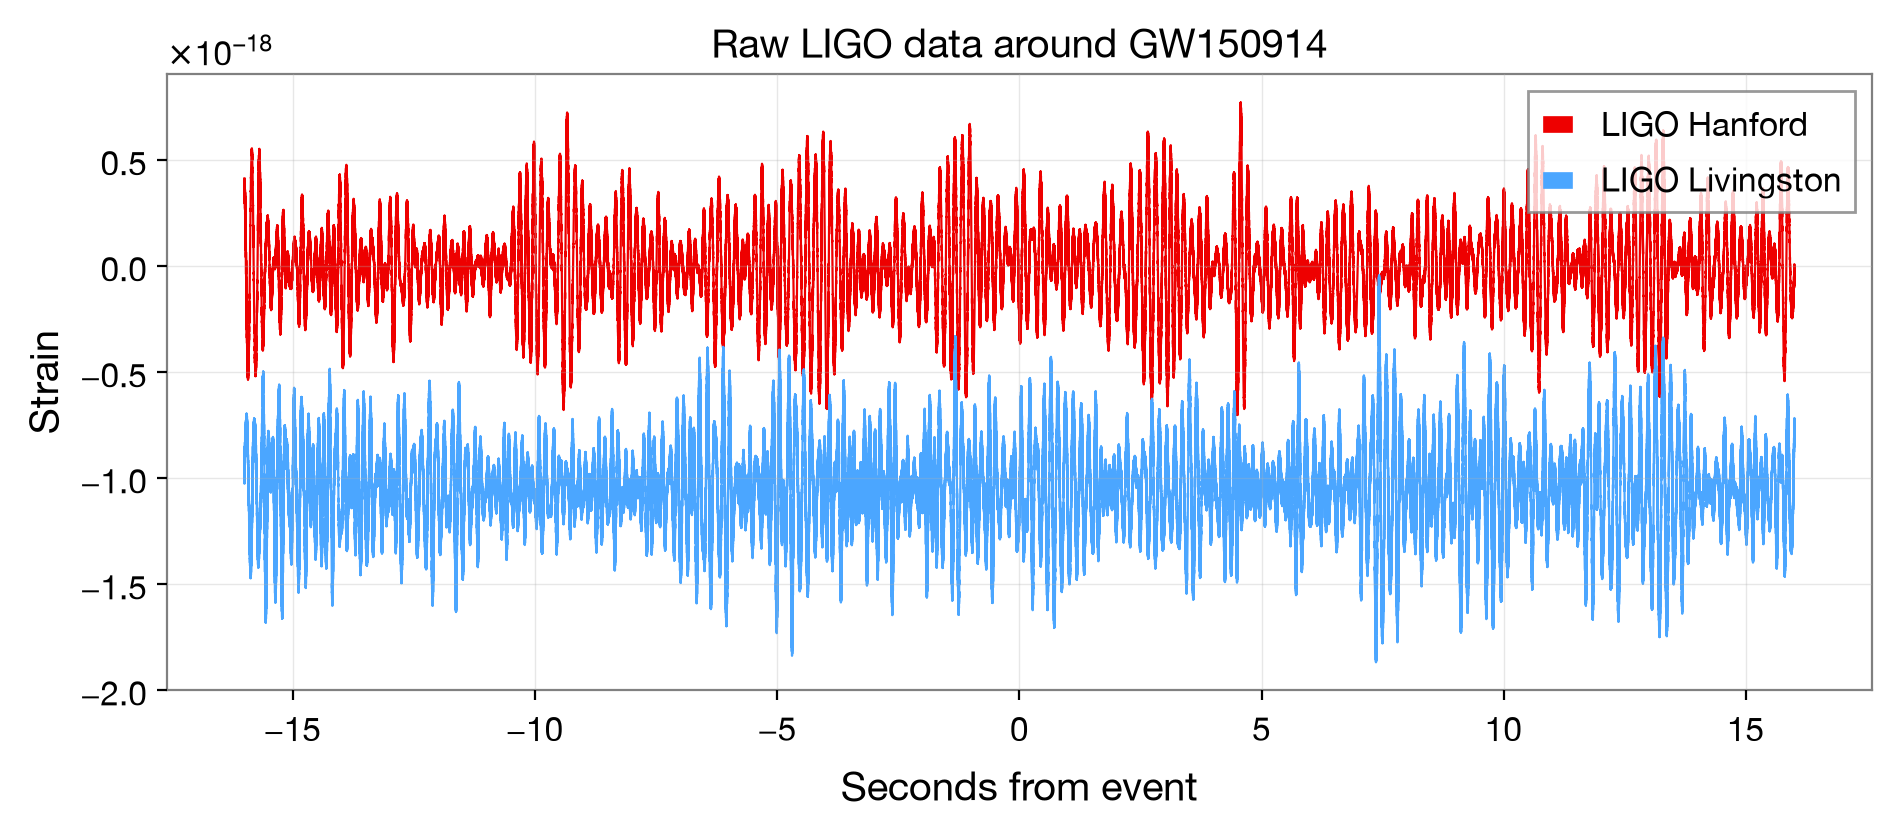

In [23]:
fig, ax = plt.subplots()
for ifo, ts in data.items():
    ax.plot(ts.times.value - gps, ts.value, color=COLORS[ifo], label=NAMES[ifo], lw=0.8)
ax.set(xlabel="Seconds from event", ylabel="Strain", title="Raw LIGO data around GW150914")
ax.legend(loc="upper right");

**Hmm, where's the signal?** 🤔 The raw data is dominated by **noise** that is about 1,000 times bigger than the wave we're looking for.
To find it we need to understand the noise.

## 4. What is all that noise?

Let's break the data into its **frequencies**, like an equalizer on a stereo. This plot is called the
*amplitude spectral density*: the lower the curve, the quieter the detector at that pitch.

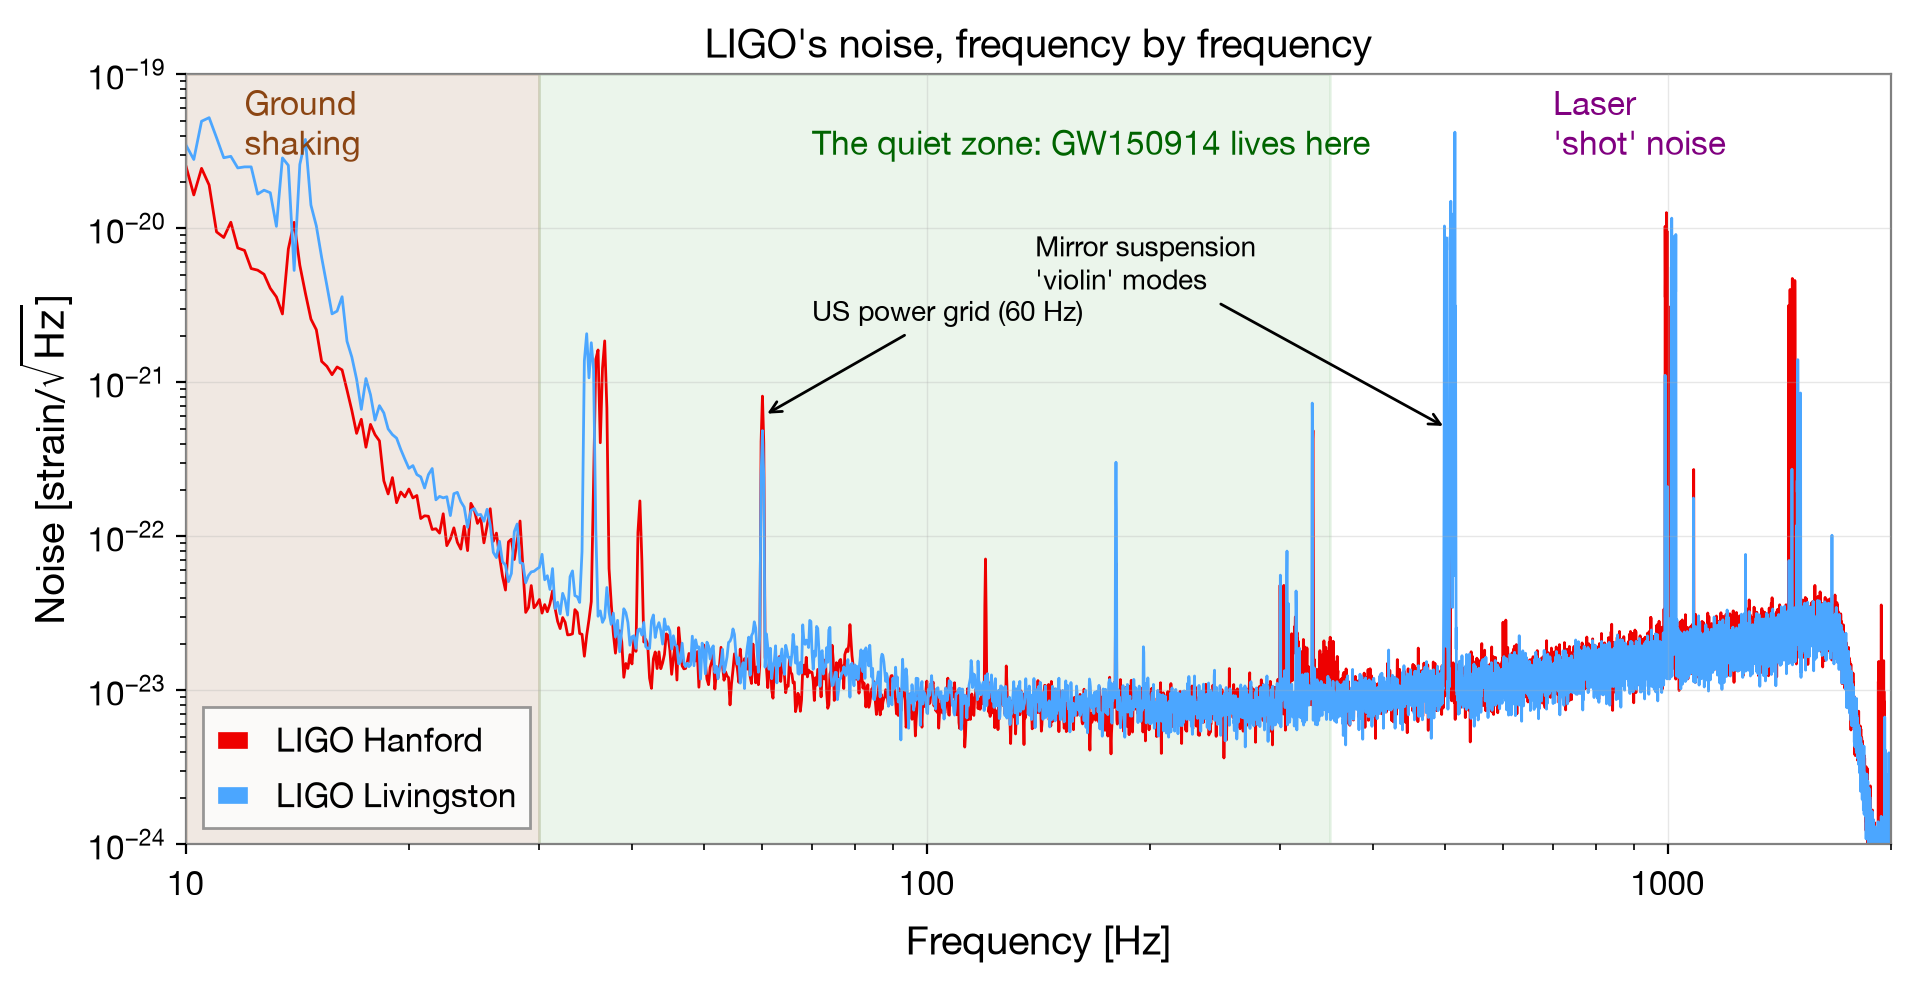

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
for ifo, ts in data.items():
    asd = ts.asd(fftlength=4, overlap=2)
    ax.loglog(asd.frequencies, asd, color=COLORS[ifo], label=NAMES[ifo], lw=1)

ax.axvspan(10, 30, color="saddlebrown", alpha=0.12)
ax.axvspan(30, 350, color="green", alpha=0.08)
ax.text(12, 3e-20, "Ground\nshaking", color="saddlebrown")
ax.text(70, 3e-20, "The quiet zone: GW150914 lives here", color="darkgreen")
ax.text(700, 3e-20, "Laser\n'shot' noise", color="purple")
ax.annotate("US power grid (60 Hz)", xy=(60, 6e-22), xytext=(70, 2.5e-21),
            arrowprops=dict(arrowstyle="->"), fontsize=10)
ax.annotate("Mirror suspension\n'violin' modes", xy=(505, 5e-22), xytext=(140, 4e-21),
            arrowprops=dict(arrowstyle="->"), fontsize=10)
ax.set(xlim=(10, 2000), ylim=(1e-24, 1e-19), xlabel="Frequency [Hz]",
       ylabel=r"Noise [strain/$\sqrt{\mathrm{Hz}}$]", title="LIGO's noise, frequency by frequency")
ax.legend(loc="lower left");

## 5. Cleaning the signal

We clean the data in three steps, each one line of code:

1. **Whiten**: rescale every frequency so the noise is equally loud at all pitches, like turning down the parts of the equalizer that are too loud.
2. **Bandpass**: keep only 35–350 Hz, the quiet zone.
3. **Notch**: cut out the power-grid hum at 60, 120 and 180 Hz.

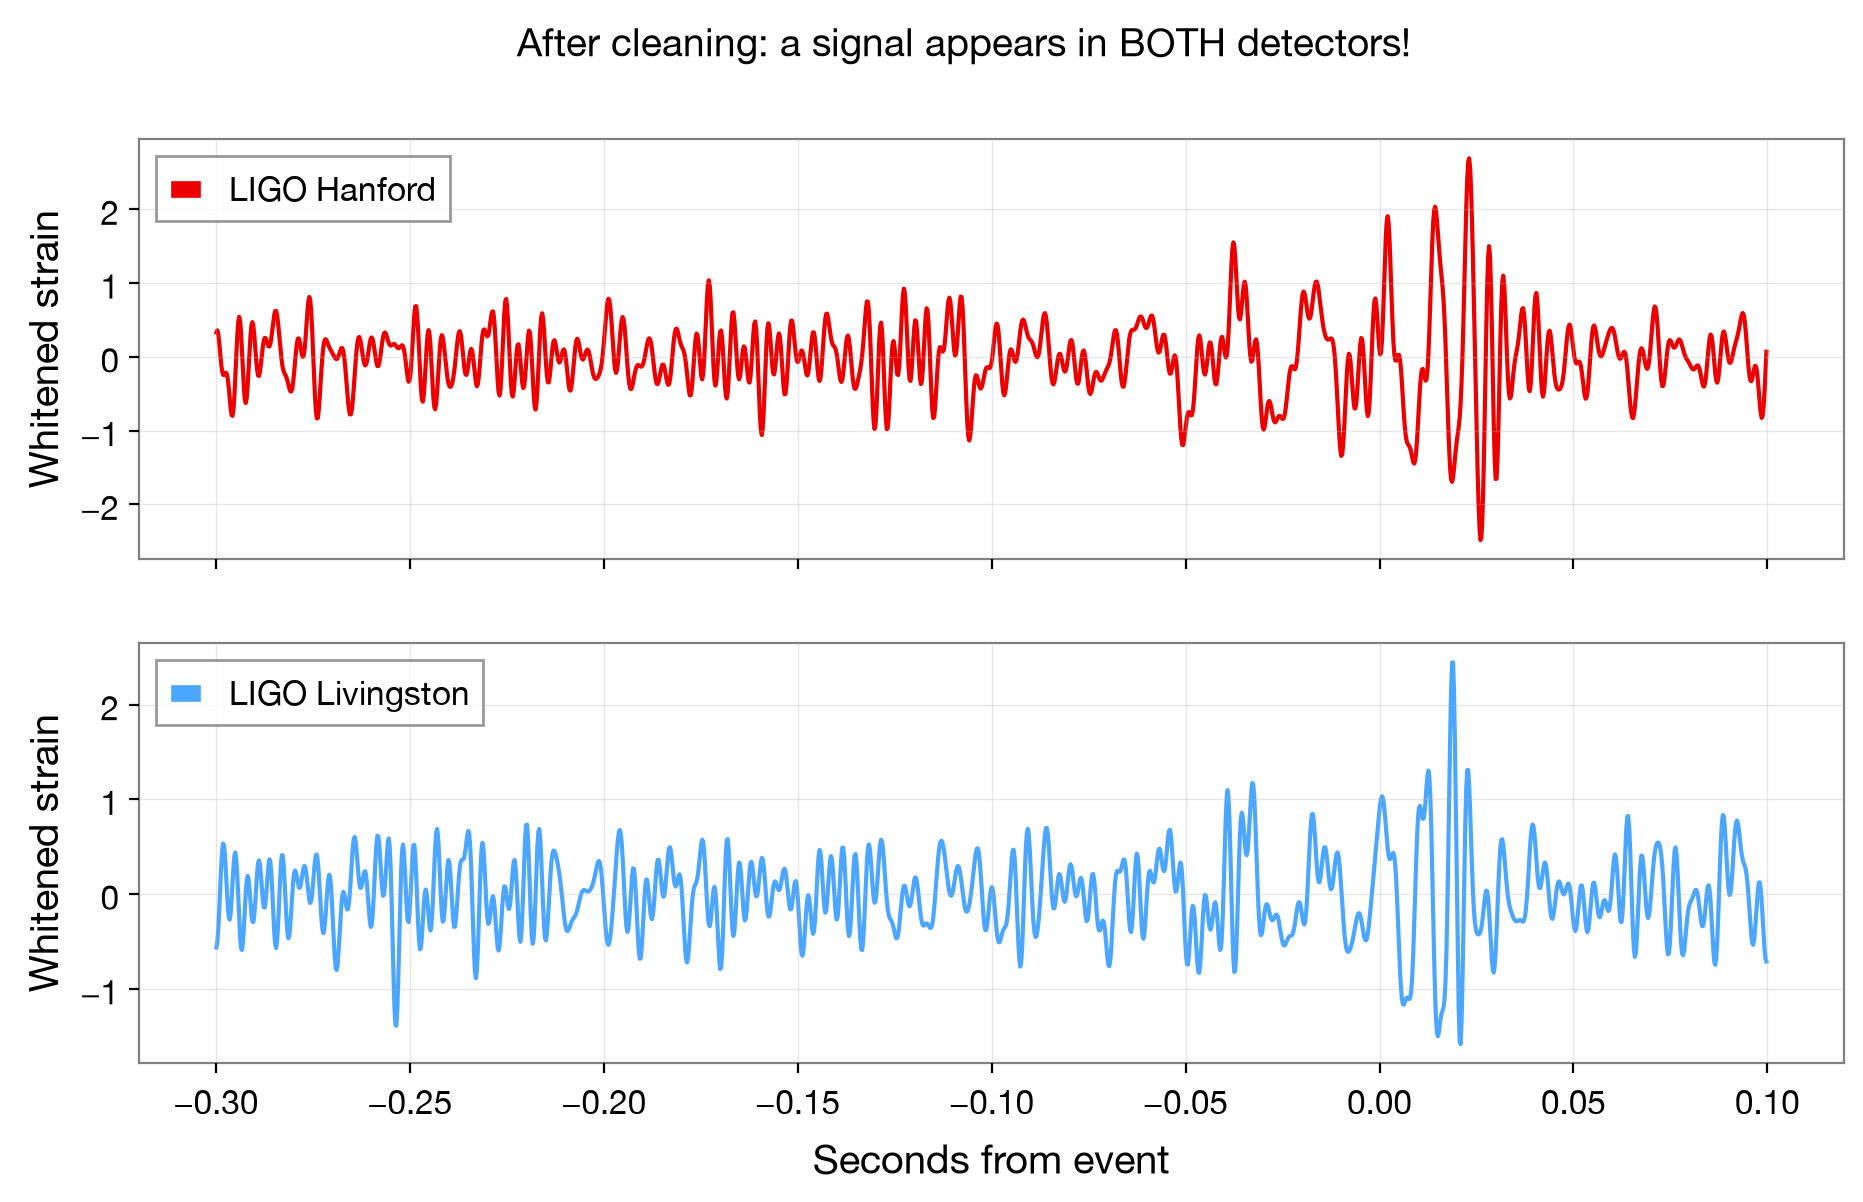

In [25]:
from gwpy.signal import filter_design

fs = data["H1"].sample_rate
bandpass = filter_design.bandpass(35, 350, fs)
notches = [filter_design.notch(f, fs) for f in (60, 120, 180)]
zpk = filter_design.concatenate_zpks(bandpass, *notches)

clean = {ifo: ts.whiten(4, 2).filter(zpk, filtfilt=True) for ifo, ts in data.items()}

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, (ifo, ts) in zip(axes, clean.items()):
    seg = ts.crop(gps - 0.3, gps + 0.1)
    ax.plot(seg.times.value - gps, seg.value, color=COLORS[ifo], label=NAMES[ifo])
    ax.set_ylabel("Whitened strain")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Seconds from event")
fig.suptitle("After cleaning: a signal appears in BOTH detectors!", fontsize=14);

### Did the signal travel at the speed of light? ⚡

If this is a real wave from space, it reached the two detectors at slightly different times. We can find the delay
by sliding one signal over the other until they line up best:

In [26]:
h1 = clean["H1"].crop(gps - 0.2, gps + 0.05).value
l1 = clean["L1"].crop(gps - 0.2, gps + 0.05).value
lags = np.arange(-60, 61)   # samples (each is 1/4096 s)
# L1 is flipped (-) because the two detectors' arms point in different directions
match = [np.dot(h1, -np.roll(l1, k)) for k in lags]
delay = (lags[np.argmax(match)] / fs.value * u.s).to(u.ms)

distance = 3002 * u.km
light_time = (distance / const.c).to(u.ms)

display(Markdown(f'''
- Measured delay between detectors: **{delay:.1f}** (Livingston heard it first)
- Light travel time between the sites: **{light_time:.1f}**

✅ The delay is less than light-travel time, consistent with a wave from space moving at the speed of light.
'''))


- Measured delay between detectors: **7.3 ms** (Livingston heard it first)
- Light travel time between the sites: **10.0 ms**

✅ The delay is less than light-travel time, consistent with a wave from space moving at the speed of light.


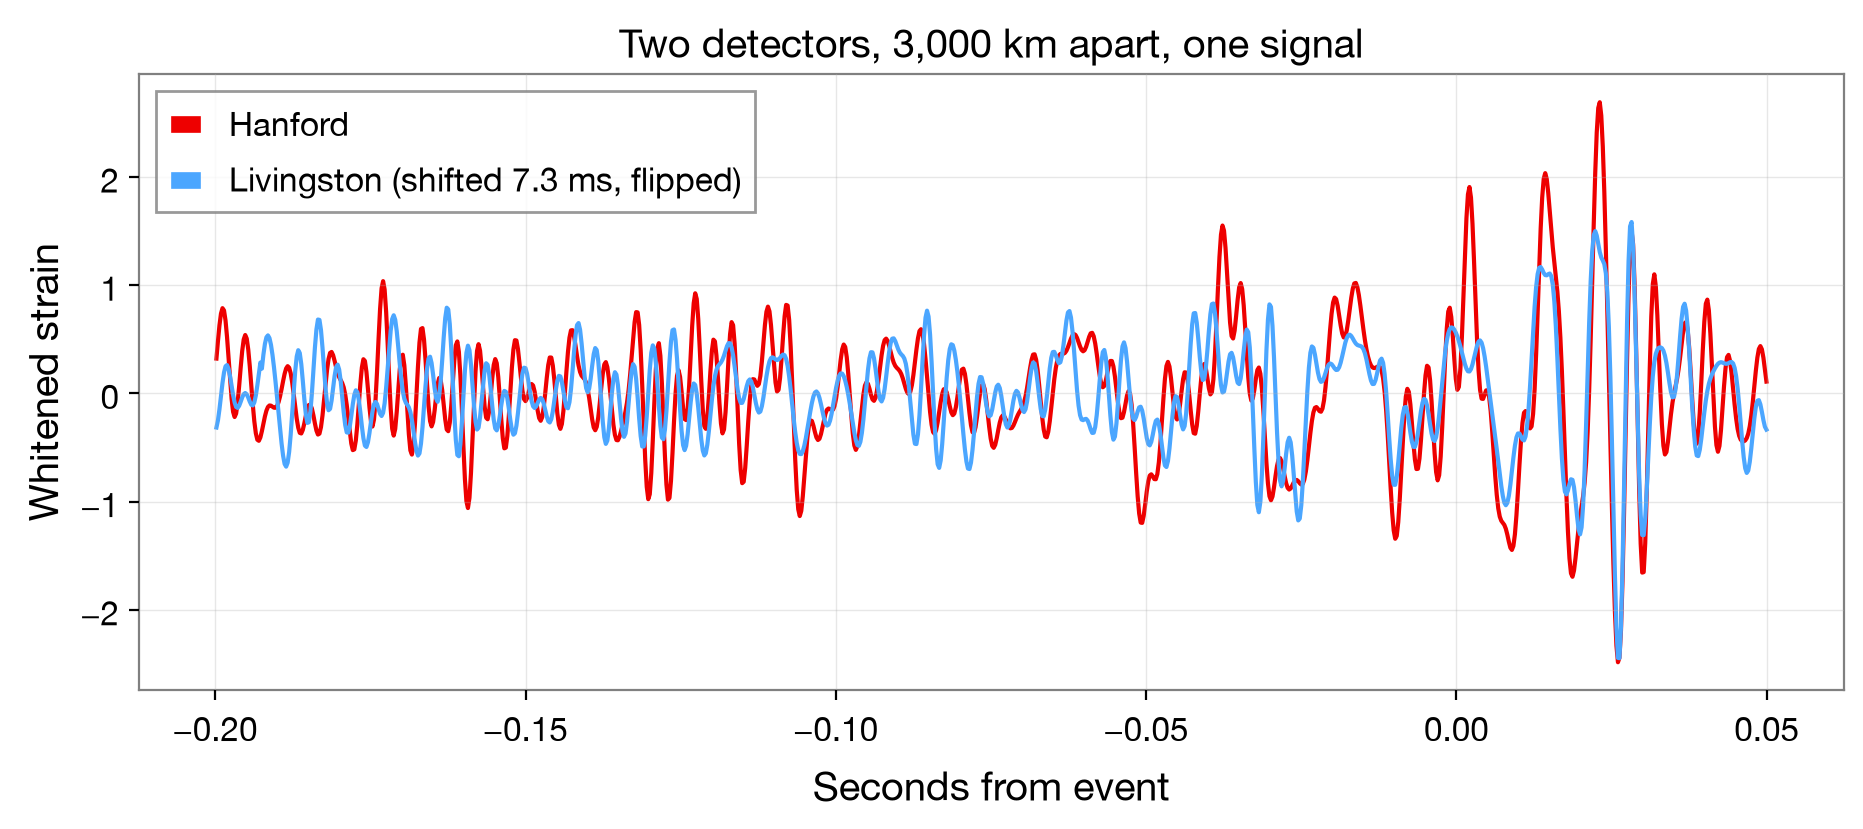

In [27]:
fig, ax = plt.subplots()
t = clean["H1"].crop(gps - 0.2, gps + 0.05).times.value - gps
ax.plot(t, h1, color=COLORS["H1"], label="Hanford")
ax.plot(t, -np.roll(l1, lags[np.argmax(match)]), color=COLORS["L1"], label=f"Livingston (shifted {delay:.1f}, flipped)")
ax.set(xlabel="Seconds from event", ylabel="Whitened strain", title="Two detectors, 3,000 km apart, one signal")
ax.legend(loc="upper left");

## 6. Listen to it 🔊

The wave's frequencies happen to fall in the range human ears can hear, so we can **play the data as sound**.
Listen for a short rising **"whoop"**, the *chirp*, at the very end.

In [10]:
def tukey_window(n, alpha=0.1):
    from scipy.signal.windows import tukey
    return tukey(n, alpha)

snippet = clean["H1"].crop(gps - 1.5, gps + 0.5)
sound = snippet.value * tukey_window(len(snippet))
display(Markdown("**The real data, as recorded by LIGO Hanford:**"))
Audio(sound, rate=int(fs.value))

**The real data, as recorded by LIGO Hanford:**

In [11]:
# The chirp is low-pitched; shift every frequency up by 400 Hz so it's easier to hear
def shift_frequency(x, shift_hz, rate):
    spectrum = np.fft.rfft(x)
    spectrum = np.roll(spectrum, int(shift_hz * len(x) / rate))
    return np.fft.irfft(spectrum, n=len(x))

display(Markdown("**Same data, shifted up 400 Hz in pitch:**"))
Audio(shift_frequency(sound, 400, fs.value) * tukey_window(len(sound)), rate=int(fs.value))

**Same data, shifted up 400 Hz in pitch:**

## 7. Seeing the chirp

A **spectrogram** shows *which pitches are present at each moment in time*. It's how scientists "see" a sound.
LIGO uses a version tuned for chirps called the **Q-transform**. This is the image that went around the world:

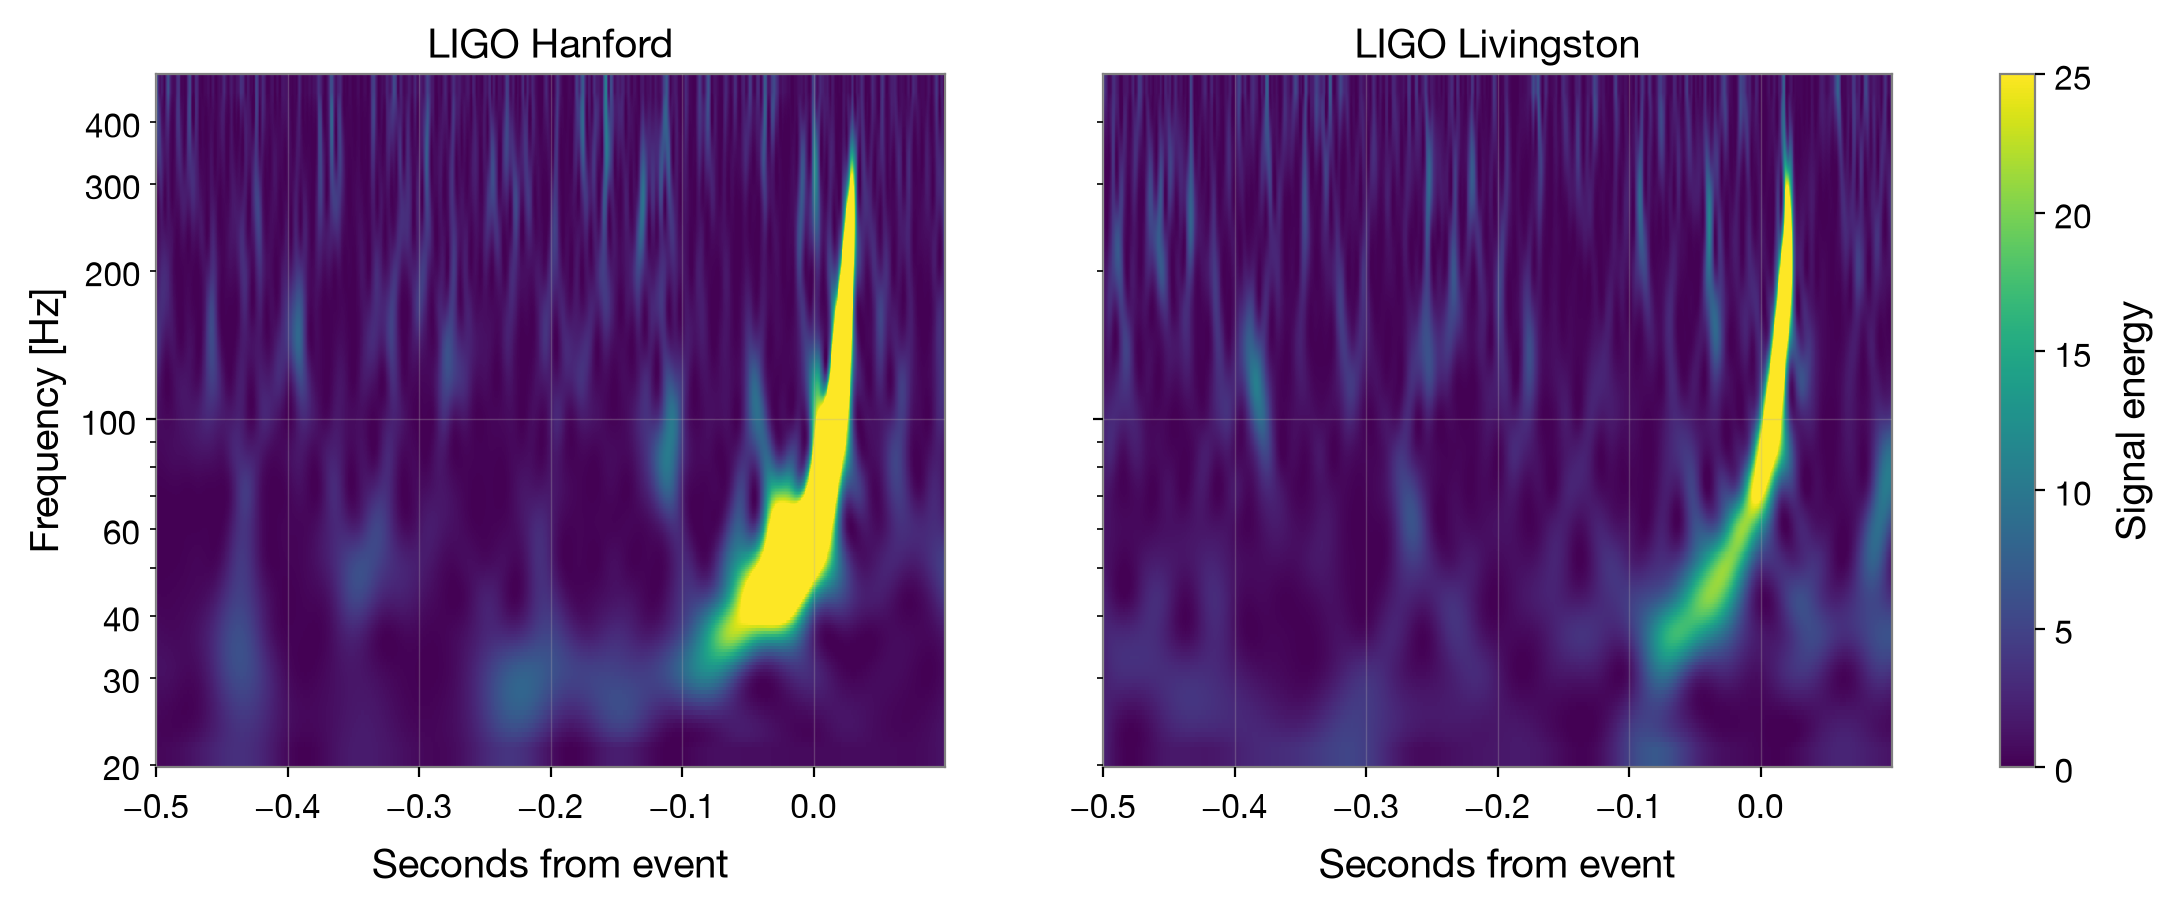

In [28]:
qscans = {ifo: ts.q_transform(outseg=(gps - 0.5, gps + 0.1), qrange=(4, 64), frange=(20, 500))
          for ifo, ts in data.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (ifo, q) in zip(axes, qscans.items()):
    mesh = ax.pcolormesh(q.times.value - gps, q.frequencies.value, q.value.T, vmin=0, vmax=25, cmap="viridis", shading="auto")
    ax.set(yscale="log", xlabel="Seconds from event", title=NAMES[ifo])
axes[0].set_ylabel("Frequency [Hz]")
fig.colorbar(mesh, ax=axes, label="Signal energy");

The signal **sweeps upward in pitch** from about 35 Hz to 250 Hz in a fifth of a second. This is the final moments of two black holes spiraling
together, orbiting faster and faster, until they **merge**.

## 8. Weighing the black holes ⚖️

Einstein's theory predicts **exactly** how the pitch should rise. To a good approximation the frequency at a time $\tau$
before the collision depends on just one number, the **chirp mass** $\mathcal{M}$:

$$
f(\tau) = \frac{1}{\pi}\left(\frac{5}{256\,\tau}\right)^{3/8}\left(\frac{G\mathcal{M}}{c^3}\right)^{-5/8}
\qquad\text{where}\qquad
\mathcal{M} = \frac{(m_1 m_2)^{3/5}}{(m_1+m_2)^{1/5}}
$$

Heavier systems chirp **lower and faster**. So the shape of the chirp tells us how heavy the objects are.

**👉 Drag the slider** until the white prediction traces the bright chirp:

In [29]:
T_MERGER = gps + 0.03   # moment of collision (seconds)

def chirp_frequency(tau, chirp_mass):
    # Leading-order (Newtonian) chirp: tau in seconds, chirp_mass in solar masses
    tc = (const.G * chirp_mass * const.M_sun / const.c**3).to_value(u.s)
    return (1 / np.pi) * (5 / (256 * tau)) ** (3 / 8) * tc ** (-5 / 8)

q = qscans["H1"]
t_q = q.times.value - gps

def show_fit(chirp_mass=10.0):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.pcolormesh(t_q, q.frequencies.value, q.value.T, vmin=0, vmax=25, cmap="viridis", shading="auto")
    tau = np.linspace(0.5, 0.004, 400)
    f = chirp_frequency(tau, chirp_mass)
    ax.plot(T_MERGER - gps - tau, f, color="white", lw=2.5, ls="--", label=f"Einstein's prediction for $\\mathcal{{M}}$ = {chirp_mass:.0f} M$_\\odot$")
    ax.set(yscale="log", ylim=(20, 500), xlim=(-0.5, 0.1), xlabel="Seconds from event", ylabel="Frequency [Hz]",
           title=f"Chirp mass = {chirp_mass:.0f} times the mass of the Sun")
    ax.legend(loc="upper left")
    plt.show()

widgets.interact(show_fit, chirp_mass=widgets.FloatSlider(value=10, min=5, max=60, step=1,
                 description="Chirp mass", continuous_update=False, layout=widgets.Layout(width="600px")));

interactive(children=(FloatSlider(value=10.0, continuous_update=False, description='Chirp mass', layout=Layout…

The best match is around **$\mathcal{M} \approx 30$ solar masses**. If the two objects weigh about the same, each is about **35 times the mass of the Sun**,
squeezed into a sphere only a couple of hundred kilometers across. Only **black holes** are that dense.

LIGO's full analysis found **36 and 29 solar masses**, so our 30-second slider got remarkably close.

Here's what Einstein's equations predict a chirp with that mass *sounds* like. Compare it to the real data above:

In [30]:
def model_chirp(chirp_mass, rate=4096, duration=1.5):
    tau = np.linspace(duration, 1 / rate, int(duration * rate))
    f = np.minimum(chirp_frequency(tau, chirp_mass), 300)
    phase = 2 * np.pi * np.cumsum(f) / rate
    return (f / f.max()) ** (2 / 3) * np.cos(phase) * tukey_window(len(tau), 0.05)

Audio(shift_frequency(model_chirp(30), 400, 4096), rate=4096)

### How much energy was released? 💥

The final black hole weighed about **3 solar masses less** than the two it formed from. That mass became gravitational-wave energy,
via the most famous equation in physics, $E = mc^2$:

In [31]:
E = (3 * const.M_sun * const.c**2).to(u.J)
peak_power = 3.6e49 * u.W                                # LIGO's measured peak luminosity
sun_lifetime_energy = (const.L_sun * 10 * u.Gyr).to(u.J)

display(Markdown(f'''
| | |
|---|---|
| Energy radiated | **{E:.1e}** |
| Equal to | the Sun's **entire 10-billion-year output, {(E / sun_lifetime_energy).decompose():,.0f} times over** |
| Peak power | **{peak_power:.1e}**, about **{(peak_power / const.L_sun).decompose():.0e} Suns** |
| In comparison | more than **all the stars in the observable universe combined**, for a fraction of a second |
'''))


| | |
|---|---|
| Energy radiated | **5.4e+47 J** |
| Equal to | the Sun's **entire 10-billion-year output, 4,438 times over** |
| Peak power | **3.6e+49 W**, about **9e+22 Suns** |
| In comparison | more than **all the stars in the observable universe combined**, for a fraction of a second |


## 9. A new window on the universe 🔭

- **3 October 2017:** the Nobel Prize in Physics went to **Rainer Weiss, Barry Barish and Kip Thorne**
  *"for decisive contributions to the LIGO detector and the observation of gravitational waves."*
- **17 August 2017:** LIGO and Virgo detected two **neutron stars** colliding (GW170817). Telescopes around the world then saw the explosion in light,
  confirming that such collisions forge gold and platinum.

Since then, detections have become routine. Let's load GWOSC's list of **every confirmed event** (saved from the [GWOSC event API](https://gwosc.org/eventapi/json/allevents/)) and plot them:

In [32]:
import json
import pandas as pd

events = json.load(open("data/gwosc_events.json"))["events"]
df = pd.DataFrame(events.values())
df = df[df["catalog.shortName"].str.startswith("GWTC") & ~df["catalog.shortName"].str.contains("marginal")
        & (df["catalog.shortName"] != "GWTC-2") & df["mass_1_source"].notna()]
df = df.sort_values("version").drop_duplicates("commonName", keep="last")   # latest analysis of each event
df["total_mass"] = df["mass_1_source"] + df["mass_2_source"]
df["distance_gly"] = (df["luminosity_distance"].values * u.Mpc).to(u.lyr).value / 1e9
df["date"] = pd.to_datetime(df["GPS"] + 315964800 - 18, unit="s")   # GPS -> UTC

print(f"{len(df)} confirmed gravitational-wave detections")
df[["commonName", "mass_1_source", "mass_2_source", "distance_gly"]].sort_values("mass_1_source", ascending=False).head()

282 confirmed gravitational-wave detections


,commonName,mass_1_source,mass_2_source,distance_gly
213,GW231123_135430,137.0,101.0,7.175440
596,GW190426_190642,105.5,76.0,14.937962
577,GW190521,98.4,57.2,10.795776
249,GW231028_153006,94.0,59.0,13.698568
384,GW230704_212616,89.0,50.0,23.809416


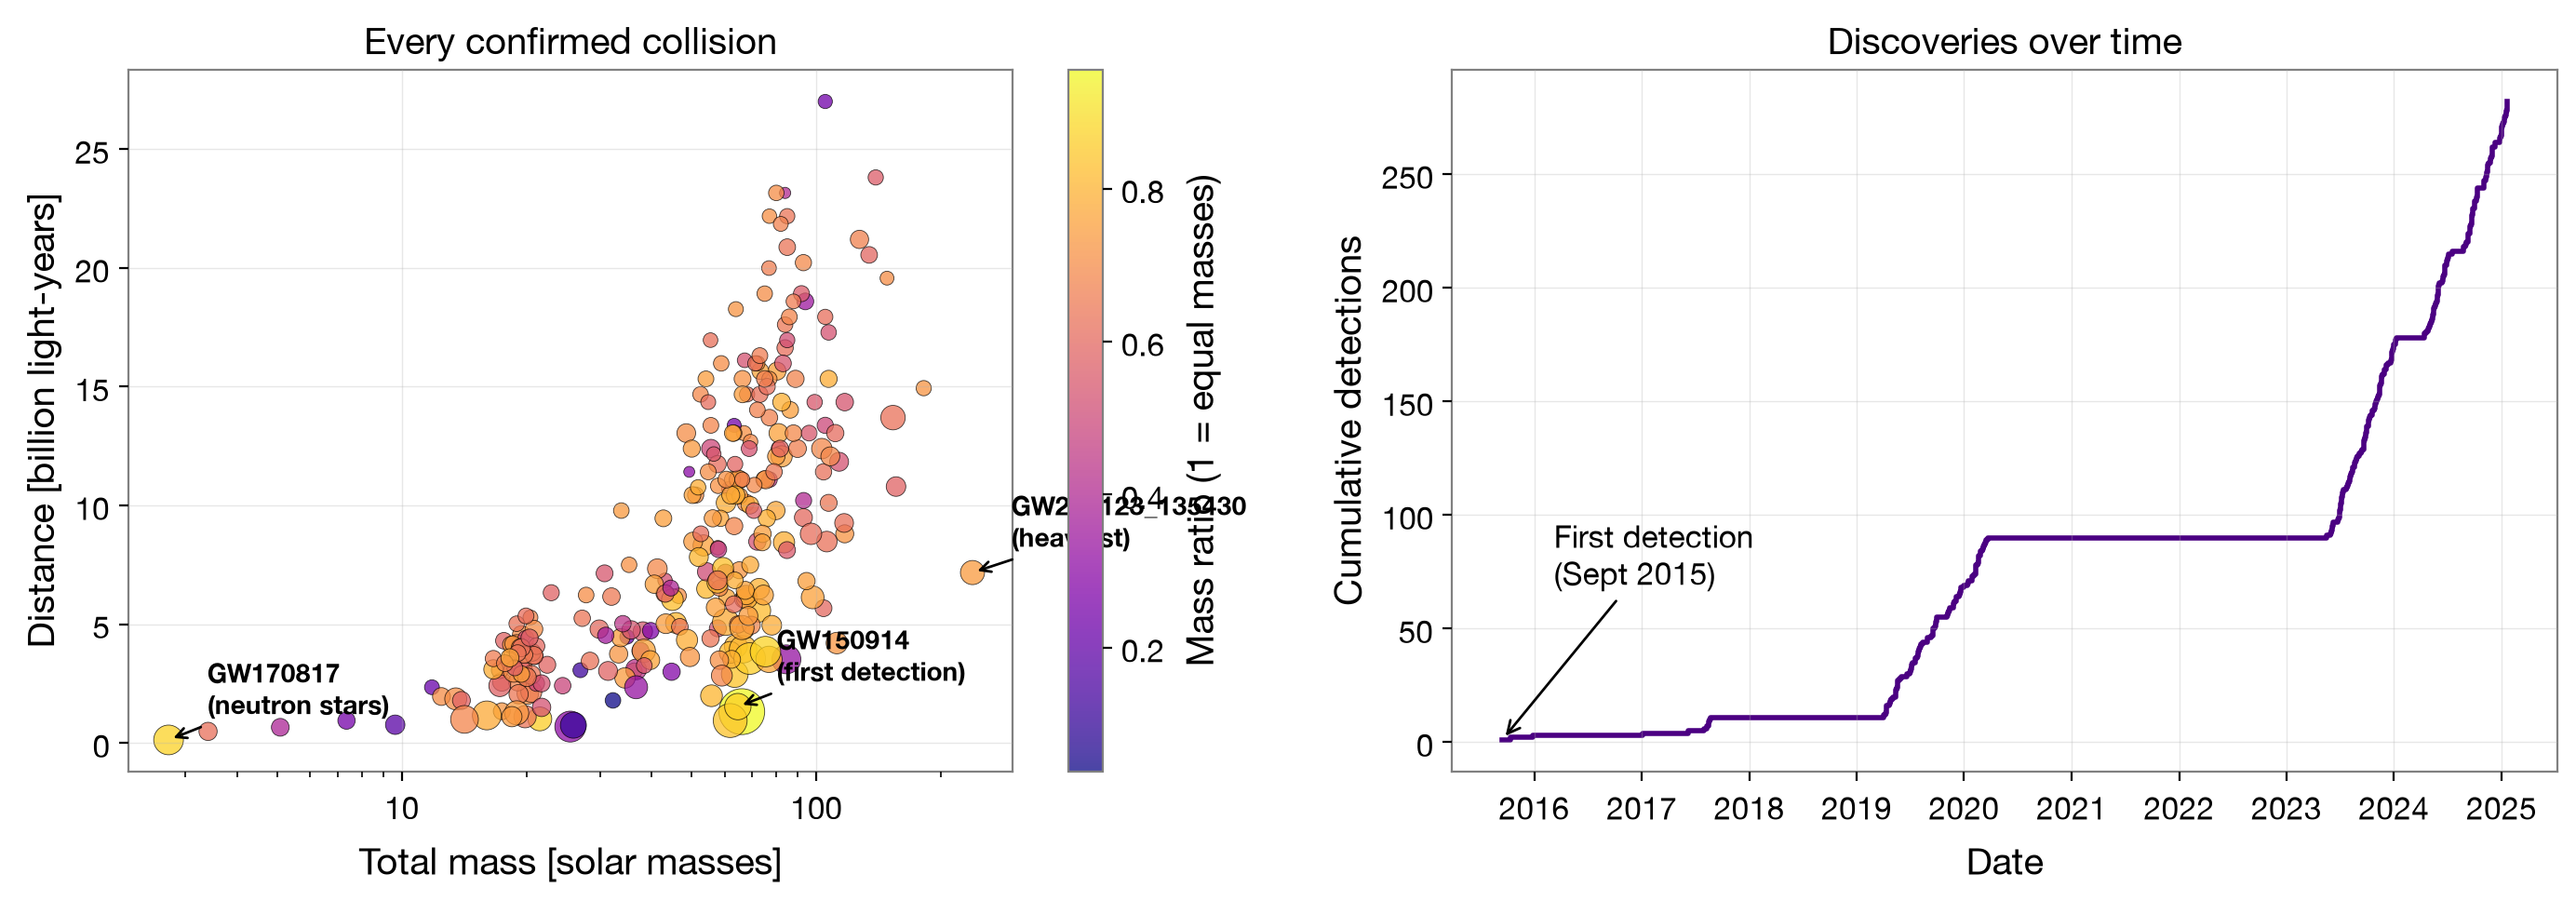

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc = ax1.scatter(df["total_mass"], df["distance_gly"], s=df["network_matched_filter_snr"] * 4,
                 c=df["mass_2_source"] / df["mass_1_source"], cmap="plasma", alpha=0.75, edgecolor="k", lw=0.3)
heaviest = df.loc[df["total_mass"].idxmax(), "commonName"]
for name, label in [("GW150914", "GW150914\n(first detection)"), ("GW170817", "GW170817\n(neutron stars)"),
                    (heaviest, f"{heaviest}\n(heaviest)")]:
    row = df[df["commonName"] == name].iloc[0]
    ax1.annotate(label, (row["total_mass"], row["distance_gly"]), xytext=(15, 10), textcoords="offset points",
                 arrowprops=dict(arrowstyle="->"), fontsize=10, fontweight="bold")
ax1.set(xscale="log", xlabel="Total mass [solar masses]", ylabel="Distance [billion light-years]",
        title="Every confirmed collision")
fig.colorbar(sc, ax=ax1, label="Mass ratio (1 = equal masses)")

dates = df["date"].sort_values()
ax2.step(dates, np.arange(1, len(dates) + 1), where="post", color="#4b0082", lw=2)
ax2.set(xlabel="Date", ylabel="Cumulative detections", title="Discoveries over time")
ax2.annotate("First detection\n(Sept 2015)", (dates.iloc[0], 1), xytext=(20, 60), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"))
fig.tight_layout();

## 10. Why notebooks? 📓

In a few minutes we went from **raw public data** to a **Nobel Prize–winning result**, and everything is in one document:

| | What we used it for |
|---|---|
| ✍️ **Narrative** | The story, explained alongside the analysis |
| ➗ **Math** | Einstein's equation and the chirp formula, typeset with LaTeX |
| 🖼️ **Images** | The observatories and how they work |
| 🧮 **Live code** | Downloading, cleaning and analyzing real data |
| 📈 **Plots** | Noise spectra, signals, spectrograms and the event catalog |
| 🔊 **Sound** | Hearing the black holes merge |
| 🎚️ **Interactivity** | Weighing black holes with a slider |

Anyone can **re-run every step** and check the result. This is how LIGO published its own [tutorials](https://gwosc.org/tutorials/)
for GW150914. Notebooks have become a standard way of sharing reproducible science.

---

### 🤖 Your turn: go further with AI

With Claude running in JupyterLab's terminal and connected to this notebook, try asking:

- *"Repeat this analysis for **GW170817**, the neutron star collision. It lasted about 100 seconds, so adjust the time window and frequency range."*
- *"Add **Virgo** (V1) data for **GW170814** and compare the signal across all three detectors."*
- *"Use the arrival-time delay to draw the **ring on the sky** where GW150914 could have come from."*
- *"Replace the chirp-mass slider with an **automatic best fit**, and show the uncertainty."*
- *"Build a dropdown widget that lets me pick **any event** from the catalog and see its chirp."*
- *"Which event in the catalog was the **farthest away**? Plot its Q-transform next to GW150914."*

---

<small>

**Credits.** Data: [Gravitational Wave Open Science Center](https://gwosc.org) (LIGO Scientific Collaboration, Virgo Collaboration and KAGRA Collaboration).
Analysis adapted from the [GWOSC event tutorial](https://github.com/minrk/ligo-binder), the [GWpy strain example](https://github.com/ligovirgo/notebooks)
and [PyCBC's GW150914 app](https://github.com/gwastro/gwapps). Images: Wikimedia Commons (licenses noted under each image).

</small>